# Case Study 4 — Geographic Bias Analysis
**MBL549E Group B** · Merve Civcik · Hamdi Çakır · Şeyma Olcay

Bu notebook, İtalyan mimarların Wikipedia article'larındaki coğrafi bias'ı analiz eder.

**Narrative:** Aynı mimarların eserleri, yurtdışında (özellikle ABD'de) İtalya'dakilerden çok daha detaylı anlatılıyor mu?


## 1. Imports ve veri yükleme

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, mannwhitneyu

df = pd.read_pickle("dataset_rev02.pkl")
df.head()

,url,title,country,building_type,coordinates,paragraphs,first_image_url,img_npy,architect,country_clean,country_normalized,country_top,building_type_clean,building_type_group
0,https://en.wikipedia.org/wiki/565_Broome_Street,565 Broome Street,U.S.,Residential Condominiums,40.72417°N 74.00556°W,[565 Broome Streetis a luxury residential buil...,https://upload.wikimedia.org/wikipedia/commons...,"[[[2, 0, 14], [1, 0, 13], [1, 0, 13], [0, 0, 1...",Renzo Piano,u.s.,united states,united states,residential condominiums,residential
1,https://en.wikipedia.org/wiki/Academy_Museum_o...,Academy Museum of Motion Pictures,U.S.,Motion picture history,34.06333°N 118.36083°W,[TheAcademy Museum of Motion Picturesis a film...,https://upload.wikimedia.org/wikipedia/en/thum...,"[[[186, 158, 94], [186, 158, 94], [186, 158, 9...",Renzo Piano,u.s.,united states,united states,motion picture history,other
2,https://en.wikipedia.org/wiki/Accademia_Nazion...,Accademia Nazionale di Santa Cecilia Musical I...,Rome,None,41.928931°N 12.474794°E,[TheAccademia Nazionale di Santa Cecilia Music...,https://upload.wikimedia.org/wikipedia/commons...,"[[[179, 138, 94], [179, 138, 94], [179, 138, 9...",Renzo Piano,rome,italy,italy,None,unknown
3,https://en.wikipedia.org/wiki/Aquarium_of_Genoa,Aquarium of Genoa,Italy,None,44.4102889°N 8.9265472°E,[TheAquarium of Genoa(Acquario di Genova) is t...,https://upload.wikimedia.org/wikipedia/en/thum...,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",Renzo Piano,italy,italy,italy,None,unknown
4,https://en.wikipedia.org/wiki/Art_Institute_of...,Art Institute of Chicago Building,United States,None,41.8796°N 87.6237°W,[TheArt Institute of Chicago Building(initial ...,None,None,Renzo Piano,united states,united states,united states,None,unknown


### 2. Türetilmiş değişkenler

In [3]:
# Article text uzunluğu ve paragraf sayısı
df['text_length'] = df['paragraphs'].apply(
    lambda x: sum(len(p) for p in x) if isinstance(x, list) else 0
)
df['paragraph_count'] = df['paragraphs'].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
df['has_image'] = df['first_image_url'].notna().astype(int)
df['has_coords'] = df['coordinates'].notna().astype(int)
df['has_building_type'] = df['building_type'].notna().astype(int)

# Coğrafi grup
df['geo_group'] = df['country_normalized'].apply(
    lambda x: 'Italy' if x == 'italy' else 'Abroad'
)

print("Türetilmiş değişkenler eklendi.")
print(f"\ntext_length istatistikleri:\n{df['text_length'].describe().round(0)}")


Türetilmiş değişkenler eklendi.

text_length istatistikleri:
count      211.0
mean      5303.0
std       8068.0
min        303.0
25%       1592.0
50%       2687.0
75%       5686.0
max      62497.0
Name: text_length, dtype: float64


## 3. Ülke bazında boxplot — article text length

Her ülkenin Wikipedia article uzunluk dağılımını IQR boxplot ile karşılaştırıyoruz. Sadece n≥2 olan ülkeler gösteriliyor.



=== Ülke bazında istatistikler ===
                      n     Mean   Median      Std
country_normalized                                
united kingdom        3  11142.0  13938.0   8655.0
japan                 2  10432.0  10432.0  13603.0
united states        20  15559.0  10070.0  16443.0
malta                 2   8188.0   8188.0   2726.0
australia             2   4304.0   4304.0   1949.0
russia               17   5262.0   3516.0   5279.0
switzerland           2   2924.0   2924.0   2280.0
france                8   5191.0   2572.0   6474.0
italy               139   3694.0   2484.0   5331.0
germany               3   2513.0   2408.0    666.0
taiwan                2   2218.0   2218.0     62.0
netherlands           2   1485.0   1485.0   1560.0


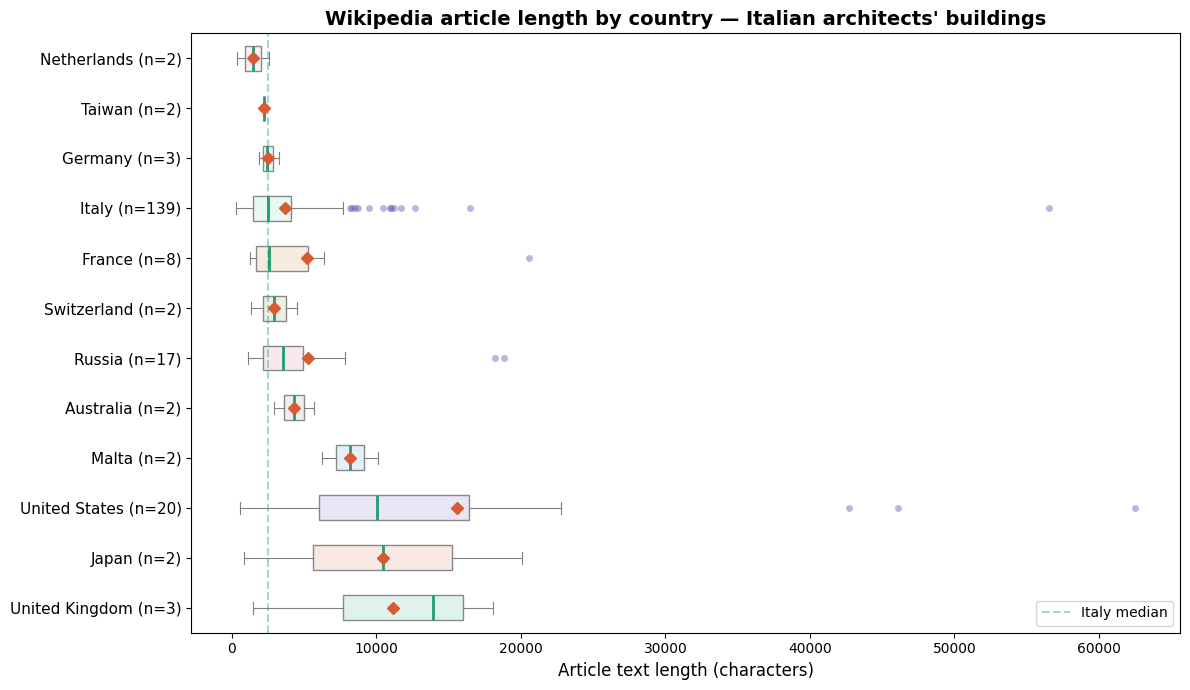

In [4]:
# Sadece n>=2 olan ülkeler
country_counts = df['country_normalized'].value_counts()
valid_countries = country_counts[country_counts >= 2].index.tolist()
df_valid = df[df['country_normalized'].isin(valid_countries)]

# Median'a göre sırala
order = df_valid.groupby('country_normalized')['text_length'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 7))
bp = ax.boxplot(
    [df_valid[df_valid['country_normalized'] == c]['text_length'].values for c in order],
    vert=False, patch_artist=True, showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='#D85A30', markeredgecolor='#D85A30', markersize=6),
    medianprops=dict(color='#1D9E75', linewidth=2),
    whiskerprops=dict(color='gray', linewidth=0.8),
    capprops=dict(color='gray', linewidth=0.8),
    flierprops=dict(marker='o', markerfacecolor='#534AB766', markeredgecolor='none', markersize=5)
)

colors_box = ['#1D9E7522', '#D85A3022', '#534AB722', '#378ADD22', '#88878022',
              '#D4537E22', '#63992222', '#BA751722', '#5DCAA522', '#85B7EB22', '#AFA9EC22', '#ED93B122']
for patch, color in zip(bp['boxes'], colors_box[:len(order)]):
    patch.set_facecolor(color)
    patch.set_edgecolor('#888')

labels = [f"{c.title()} (n={country_counts[c]})" for c in order]
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Article text length (characters)', fontsize=12)
ax.set_title('Wikipedia article length by country — Italian architects\' buildings', fontsize=14, fontweight='bold')
ax.axvline(x=df[df['country_normalized']=='italy']['text_length'].median(),
           color='#1D9E75', linestyle='--', alpha=0.4, label='Italy median')
ax.legend(loc='lower right', fontsize=10)

# İstatistik tablo
print("\n=== Ülke bazında istatistikler ===")
stats = df_valid.groupby('country_normalized')['text_length'].agg(
    ['count', 'mean', 'median', 'std']
).round(0).sort_values('median', ascending=False)
stats.columns = ['n', 'Mean', 'Median', 'Std']
print(stats.to_string())

plt.tight_layout()
plt.savefig('boxplot_by_country.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Italy vs Abroad karşılaştırması

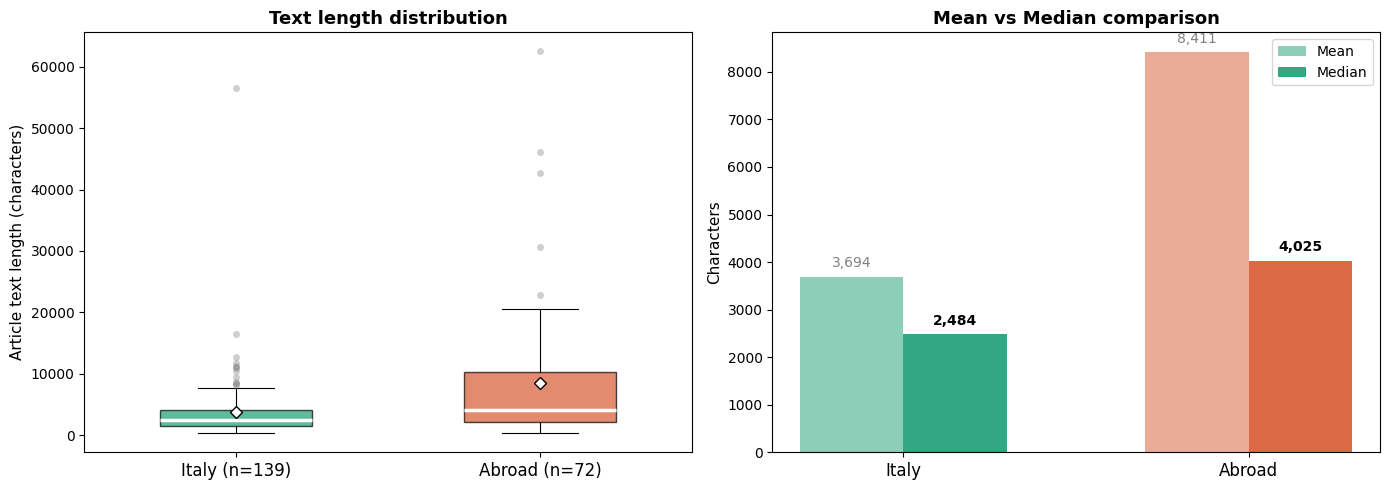


=== Mann-Whitney U test ===
H₀: Yurtdışı article'ları İtalya'dakilerden uzun değildir
U = 6604, p = 0.000071
→ H₀ REDDEDİLDİ (p < 0.05)

Italy:  mean=3,694, median=2,484, std=5,331
Abroad: mean=8,411, median=4,025, std=11,063

ABD/İtalya median oranı: 1.6x


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Sol: Boxplot ---
bp = axes[0].boxplot(
    [df[df['geo_group']=='Italy']['text_length'].values,
     df[df['geo_group']=='Abroad']['text_length'].values],
    vert=True, patch_artist=True, showmeans=True, widths=0.5,
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    flierprops=dict(marker='o', markerfacecolor='#88888866', markeredgecolor='none', markersize=5)
)
bp['boxes'][0].set_facecolor('#1D9E75')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#D85A30')
bp['boxes'][1].set_alpha(0.7)
axes[0].set_xticklabels(['Italy (n=139)', 'Abroad (n=72)'], fontsize=12)
axes[0].set_ylabel('Article text length (characters)', fontsize=11)
axes[0].set_title('Text length distribution', fontsize=13, fontweight='bold')

# --- Sağ: Bar chart (mean + median) ---
groups = ['Italy', 'Abroad']
means = [df[df['geo_group']==g]['text_length'].mean() for g in groups]
medians = [df[df['geo_group']==g]['text_length'].median() for g in groups]

x = np.arange(len(groups))
w = 0.3
axes[1].bar(x - w/2, means, w, label='Mean', color=['#1D9E75', '#D85A30'], alpha=0.5, edgecolor='none')
axes[1].bar(x + w/2, medians, w, label='Median', color=['#1D9E75', '#D85A30'], alpha=0.9, edgecolor='none')

for i, (m, md) in enumerate(zip(means, medians)):
    axes[1].text(i - w/2, m + 200, f'{m:,.0f}', ha='center', fontsize=10, color='gray')
    axes[1].text(i + w/2, md + 200, f'{md:,.0f}', ha='center', fontsize=10, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(groups, fontsize=12)
axes[1].set_ylabel('Characters', fontsize=11)
axes[1].set_title('Mean vs Median comparison', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('italy_vs_abroad.png', dpi=150, bbox_inches='tight')
plt.show()

# İstatistiksel test
italy = df[df['geo_group']=='Italy']['text_length']
abroad = df[df['geo_group']=='Abroad']['text_length']
u_stat, p_val = mannwhitneyu(abroad, italy, alternative='greater')

print(f"\n=== Mann-Whitney U test ===")
print(f"H₀: Yurtdışı article'ları İtalya'dakilerden uzun değildir")
print(f"U = {u_stat:.0f}, p = {p_val:.6f}")
print(f"{'→ H₀ REDDEDİLDİ (p < 0.05)' if p_val < 0.05 else '→ H₀ reddedilemedi'}")
print(f"\nItaly:  mean={italy.mean():,.0f}, median={italy.median():,.0f}, std={italy.std():,.0f}")
print(f"Abroad: mean={abroad.mean():,.0f}, median={abroad.median():,.0f}, std={abroad.std():,.0f}")
print(f"\nABD/İtalya median oranı: {abroad.median()/italy.median():.1f}x")


## 5. Chernoff faces — ülke bazında istatistiksel profil

Her ülkenin Mean, Median, Mode, Std, Skewness ve Kurtosis değerlerini yüz ifadesine dönüştürüyoruz.

| Yüz özelliği | İstatistik |
|---|---|
| Yüz genişliği | Mean |
| Göz boyutu | Median |
| Göz bebeği | Mode |
| Burun boyutu | Std |
| Ağız eğrisi | Skewness |
| Kaş açısı | Kurtosis |


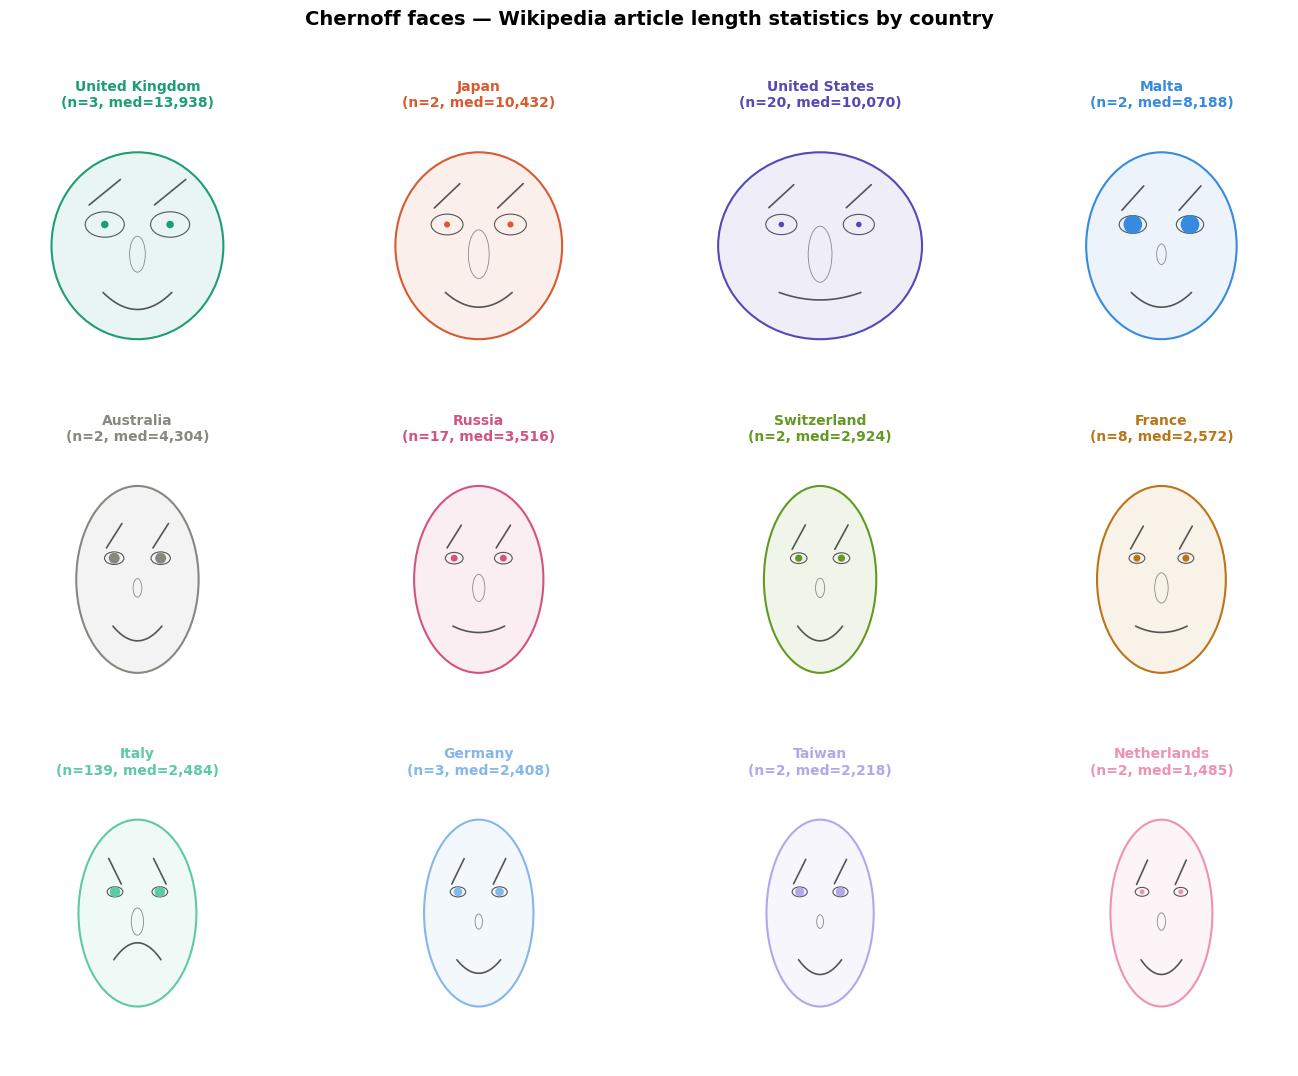

Yüz genişliği=Mean, Göz boyutu=Median, Göz bebeği=Mode
Burun boyutu=Std, Ağız eğrisi=Skewness, Kaş açısı=Kurtosis


In [6]:
def draw_chernoff(ax, stats, color, title_text):
    """Tek bir Chernoff face çiz."""
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.8, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')

    m = stats  # kısaltma

    # Yüz (mean → genişlik)
    face_w = 0.6 + m['mean_n'] * 0.6
    face_h = 1.1
    face = plt.matplotlib.patches.Ellipse((0, 0), face_w*2, face_h*2,
                                           fc=color+'18', ec=color, lw=1.5)
    ax.add_patch(face)

    # Gözler (median → boyut)
    eye_r = 0.08 + m['median_n'] * 0.15
    eye_y = 0.25
    for ex in [-face_w*0.38, face_w*0.38]:
        eye = plt.matplotlib.patches.Ellipse((ex, eye_y), eye_r*2, eye_r*1.3,
                                              fc='none', ec='#555', lw=0.8)
        ax.add_patch(eye)
        # Göz bebeği (mode)
        pupil_r = 0.03 + m['mode_n'] * 0.08
        pupil = plt.Circle((ex, eye_y), pupil_r, fc=color)
        ax.add_patch(pupil)

    # Kaşlar (kurtosis → açı)
    brow_angle = (m['kurt_n'] - 0.5) * 0.3
    brow_y = eye_y + eye_r + 0.15
    for side in [-1, 1]:
        bx = side * face_w * 0.38
        ax.plot([bx - side*eye_r*0.8, bx + side*eye_r*0.8],
                [brow_y + brow_angle*side, brow_y - brow_angle*side],
                color='#555', lw=1.2, solid_capstyle='round')

    # Burun (std → boyut)
    nose_h = 0.08 + m['std_n'] * 0.25
    nose_w = 0.04 + m['std_n'] * 0.1
    nose = plt.matplotlib.patches.Ellipse((0, -0.1), nose_w*2, nose_h*2,
                                           fc='none', ec='#888', lw=0.6)
    ax.add_patch(nose)

    # Ağız (skewness → eğri)
    mouth_curve = (m['skew_n'] - 0.5) * 0.4
    mouth_w = face_w * 0.4
    xs = np.linspace(-mouth_w, mouth_w, 30)
    ys = -0.55 + mouth_curve * (1 - (xs/mouth_w)**2)
    ax.plot(xs, ys, color='#555', lw=1.2, solid_capstyle='round')

    ax.set_title(title_text, fontsize=10, fontweight='bold', color=color, pad=8)


# Ülke istatistiklerini hesapla
country_counts = df['country_normalized'].value_counts()
valid = country_counts[country_counts >= 2].index
face_data = {}

for c in valid:
    data = df[df['country_normalized']==c]['text_length']
    face_data[c] = {
        'n': len(data),
        'mean': data.mean(), 'median': data.median(),
        'mode': data.mode().iloc[0] if len(data.mode())>0 else data.median(),
        'std': data.std() if len(data)>1 else 0,
        'skew': skew(data) if len(data)>=3 else 0,
        'kurt': kurtosis(data) if len(data)>=3 else 0,
    }

# Normalize (0-1 arası)
keys = ['mean', 'median', 'mode', 'std', 'skew', 'kurt']
for k in keys:
    vals = [face_data[c][k] for c in valid]
    vmin, vmax = min(vals), max(vals)
    rng = vmax - vmin if vmax != vmin else 1
    for c in valid:
        face_data[c][f'{k}_n'] = (face_data[c][k] - vmin) / rng

# Çiz
colors_face = ['#1D9E75','#D85A30','#534AB7','#378ADD','#888780',
               '#D4537E','#639922','#BA7517','#5DCAA5','#85B7EB','#AFA9EC','#ED93B1']

sorted_countries = sorted(valid, key=lambda c: face_data[c]['median'], reverse=True)
n_cols = 4
n_rows = int(np.ceil(len(sorted_countries) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*3.5))
axes = axes.flatten()

for i, c in enumerate(sorted_countries):
    d = face_data[c]
    color = colors_face[i % len(colors_face)]
    label = f"{c.title()}\n(n={d['n']}, med={d['median']:,.0f})"
    draw_chernoff(axes[i], d, color, label)

# Boş eksenleri gizle
for j in range(len(sorted_countries), len(axes)):
    axes[j].axis('off')

plt.suptitle('Chernoff faces — Wikipedia article length statistics by country',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chernoff_faces.png', dpi=150, bbox_inches='tight')
plt.show()

print("Yüz genişliği=Mean, Göz boyutu=Median, Göz bebeği=Mode")
print("Burun boyutu=Std, Ağız eğrisi=Skewness, Kaş açısı=Kurtosis")


## 6. Architectural Chernoff — bina formu ile istatistiksel profil

Chernoff faces'in mimari versiyonu: her ülkenin istatistiksel profili bir bina formuna dönüştürülüyor.

| Bina özelliği | İstatistik | Açıklama |
|---|---|---|
| Bina genişliği | Mean | Ortalama article uzunluğu yüksekse geniş bina |
| Bina yüksekliği | Median | Dağılımın merkezi yüksekse uzun bina |
| Çatı dikliği | Skewness | Simetrik dağılım = düz çatı, çarpık = sivri çatı |
| Pencere boyutu | Std | Yüksek varyans = büyük pencereler |
| Baca yüksekliği | Kurtosis | Sivri dağılım (extreme outlier) = uzun baca |
| Kapı genişliği | Mode | En sık değer büyükse geniş kapı |
| Kat sayısı | Median | Yüksek median = çok katlı |
| Pencere sayısı/sıra | Mean | Geniş bina (mean yüksek) = sıra başına 3 pencere |


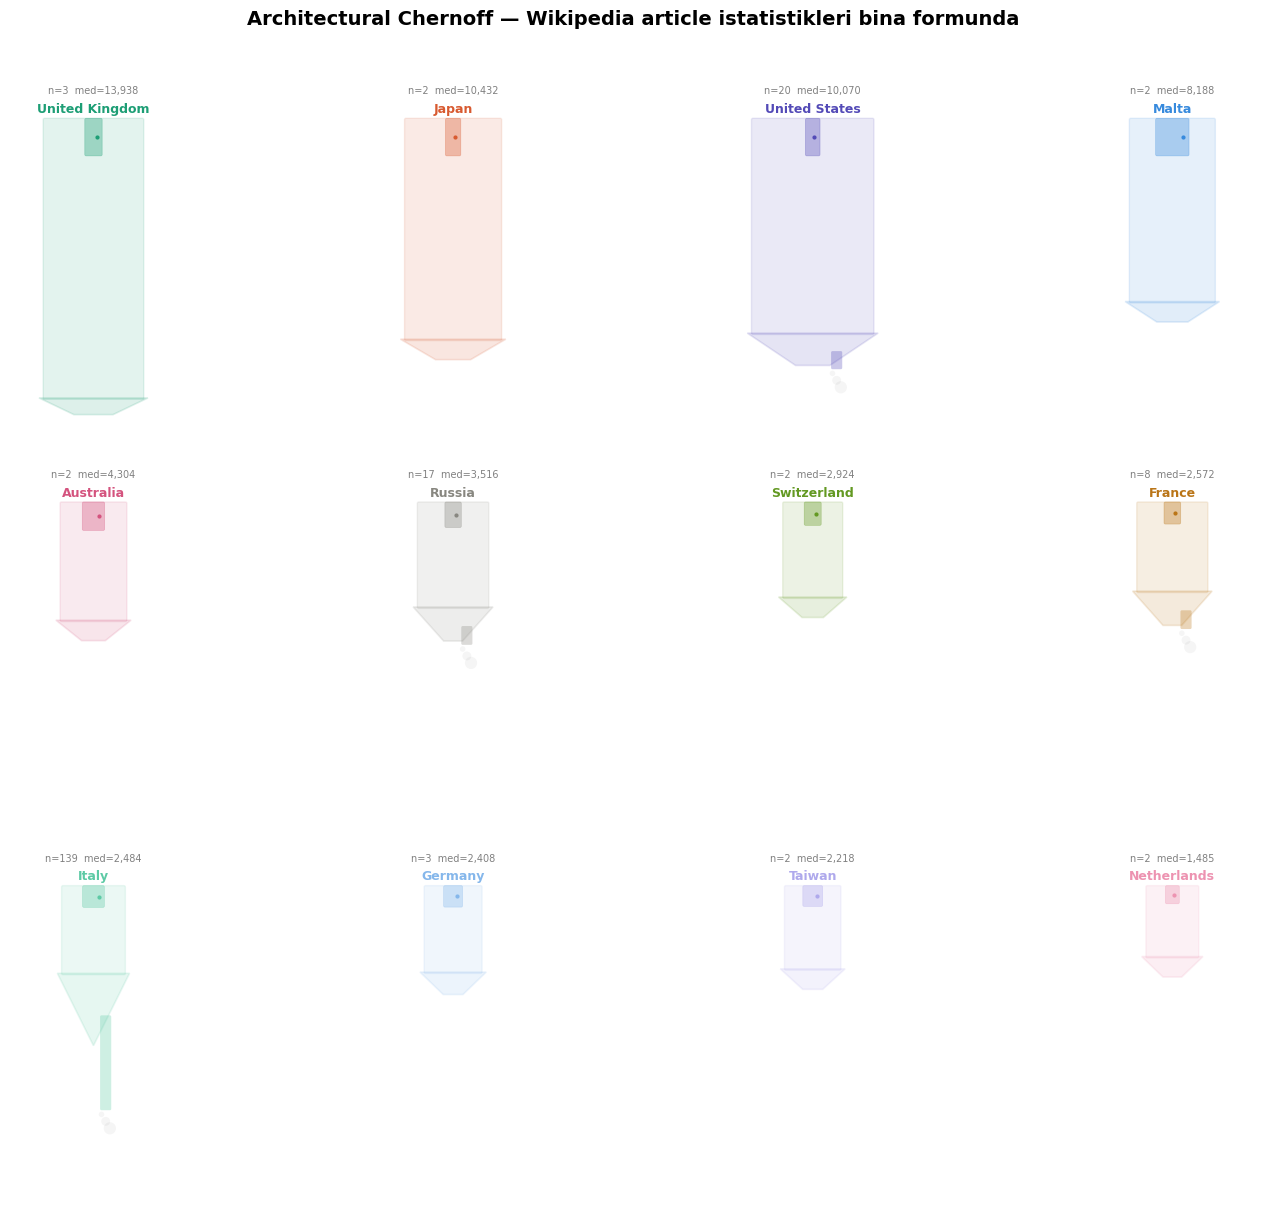


Mapping:
  Genişlik=Mean, Yükseklik=Median, Çatı dikliği=Skewness
  Pencere boyutu=Std, Baca yüksekliği=Kurtosis, Kapı genişliği=Mode
  Kat sayısı=Median, Pencere/sıra=3 (geniş bina) veya 2 (dar bina)


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import numpy as np

def normalize_range(val, all_vals):
    """Değeri 0-1 arasına normalize et."""
    mn, mx = min(all_vals), max(all_vals)
    if mx == mn:
        return 0.5
    return (val - mn) / (mx - mn)


def draw_building(ax, stats, color, label, ranges):
    """
    Tek bir mimari Chernoff bina çiz.

    stats: dict with mean, median, mode, std, skew, kurt, n
    color: hex renk kodu
    ranges: dict with all_means, all_medians, etc. for normalization
    """
    nMean = normalize_range(stats['mean'], ranges['means'])
    nMed = normalize_range(stats['median'], ranges['medians'])
    nStd = normalize_range(stats['std'], ranges['stds'])
    nMode = normalize_range(stats['mode'], ranges['modes'])
    nSkew = normalize_range(stats['skew'], ranges['skews'])
    nKurt = normalize_range(stats['kurt'], ranges['kurts'])

    # Bina boyutları
    bW = 0.36 + nMean * 0.50       # genişlik: mean
    bH = 0.50 + nMed * 1.50        # yükseklik: median
    bx = 0.5 - bW / 2              # yatay merkez
    by = 2.0 - bH                  # yerden yukarı

    # Çatı
    roof_h = 0.12 + nSkew * 0.40   # diklik: skewness
    hip_inset = bW * 0.2 * (1 - nSkew)  # hip roof genişliği
    roof_top = by - roof_h

    roof_verts = [
        (bx - 0.04, by),                     # sol alt
        (0.5 - hip_inset, roof_top),          # sol üst (hip)
        (0.5 + hip_inset, roof_top),          # sağ üst (hip)
        (bx + bW + 0.04, by),                # sağ alt
        (bx - 0.04, by),                     # kapat
    ]
    roof_codes = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
    roof_path = Path(roof_verts, roof_codes)
    roof_patch = patches.PathPatch(roof_path, fc=color, alpha=0.15, ec=color, lw=1.2)
    ax.add_patch(roof_patch)

    # Baca (kurtosis)
    chimney_h = 0.06 + nKurt * 0.55
    chimney_w = 0.06
    chimney_x = 0.5 + bW * 0.2 - chimney_w / 2
    chimney_top = roof_top - chimney_h + roof_h * 0.3

    if chimney_h > 0.08:
        chimney = patches.FancyBboxPatch(
            (chimney_x, chimney_top), chimney_w,
            roof_top - chimney_top + roof_h * 0.4,
            boxstyle="round,pad=0.01", fc=color, alpha=0.3, ec='none'
        )
        ax.add_patch(chimney)
        # Duman
        for si in range(3):
            smoke = plt.Circle(
                (chimney_x + chimney_w/2 + si*0.03 - 0.03,
                 chimney_top - 0.04 - si*0.05),
                0.02 + si*0.012, fc='gray', alpha=0.08, ec='none'
            )
            ax.add_patch(smoke)

    # Duvar
    wall = patches.FancyBboxPatch(
        (bx, by), bW, bH,
        boxstyle="round,pad=0.01", fc=color, alpha=0.12, ec=color, lw=1
    )
    ax.add_patch(wall)

    # Pencereler (std → boyut, median → kat sayısı)
    win_size = 0.06 + nStd * 0.12
    n_floors = max(1, round(1 + nMed * 3))
    n_win_per_floor = 3 if bW > 0.55 else 2

    for fl in range(n_floors):
        wy = by + 6 + fl * (bH - 0.22) / n_floors # Adjusted from 0.08 to 0.20
        for wi in range(n_win_per_floor):
            wx = bx + (wi + 1) * bW / (n_win_per_floor + 1) - win_size / 2
            if wy + win_size * 1.2 < 2.0 - 0.20:
                win = patches.FancyBboxPatch(
                    (wx, wy), win_size, win_size * 1.2,
                    boxstyle="round,pad=0.005",
                    fc='#FFDC82', alpha=0.25, ec=color, lw=0.5
                )
                ax.add_patch(win)
                # Pencere çerçevesi (artı işareti)
                ax.plot([wx + win_size/2, wx + win_size/2],
                        [wy, wy + win_size*1.2],
                        color=color, lw=0.3, alpha=0.5)
                ax.plot([wx, wx + win_size],
                        [wy + win_size*0.6, wy + win_size*0.6],
                        color=color, lw=0.3, alpha=0.5)

    # Kapı (mode → genişlik)
    door_w = 0.08 + nMode * 0.14
    door_h = min(bH * 0.22, 0.25)
    door_x = 0.5 - door_w / 2
    door_y = 2.0 - door_h

    door = patches.FancyBboxPatch(
        (door_x, door_y), door_w, door_h,
        boxstyle="round,pad=0.01", fc=color, alpha=0.35, ec=color, lw=0.5
    )
    ax.add_patch(door)
    # Kapı kolu
    ax.plot(door_x + door_w - 0.03, door_y + door_h/2,
            'o', color=color, markersize=2)

    # Label
    ax.text(0.5, 2.12, label,
            ha='center', va='top', fontsize=9, fontweight='bold', color=color)
    ax.text(0.5, 2.24, f'n={stats["n"]}  med={stats["median"]:,.0f}',
            ha='center', va='top', fontsize=7, color='gray')

    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.3, 2.35)
    ax.set_aspect('equal')
    ax.axis('off')


# ============================================================
# Veri hazırlığı
# ============================================================
country_counts = df['country_normalized'].value_counts()
valid = country_counts[country_counts >= 2].index

building_stats = {}
for c in valid:
    data = df[df['country_normalized']==c]['text_length']
    building_stats[c] = {
        'n': len(data),
        'mean': data.mean(),
        'median': data.median(),
        'mode': data.mode().iloc[0] if len(data.mode())>0 else data.median(),
        'std': data.std() if len(data)>1 else 0,
        'skew': skew(data) if len(data)>=3 else 0,
        'kurt': kurtosis(data) if len(data)>=3 else 0,
    }

# Normalizasyon için tüm değerleri topla
ranges = {
    'means': [s['mean'] for s in building_stats.values()],
    'medians': [s['median'] for s in building_stats.values()],
    'stds': [s['std'] for s in building_stats.values()],
    'modes': [s['mode'] for s in building_stats.values()],
    'skews': [s['skew'] for s in building_stats.values()],
    'kurts': [s['kurt'] for s in building_stats.values()],
}

colors_bldg = ['#1D9E75','#D85A30','#534AB7','#378ADD','#D4537E',
               '#888780','#639922','#BA7517','#5DCAA5','#85B7EB','#AFA9EC','#ED93B1']

# Median'a göre sırala
sorted_countries = sorted(valid, key=lambda c: building_stats[c]['median'], reverse=True)

n_cols = 4
n_rows = int(np.ceil(len(sorted_countries) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, c in enumerate(sorted_countries):
    s = building_stats[c]
    color = colors_bldg[i % len(colors_bldg)]
    label = c.title()
    draw_building(axes[i], s, color, label, ranges)

# Boş eksenleri gizle
for j in range(len(sorted_countries), len(axes)):
    axes[j].axis('off')

plt.suptitle('Architectural Chernoff — Wikipedia article istatistikleri bina formunda',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('architectural_chernoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMapping:")
print("  Genişlik=Mean, Yükseklik=Median, Çatı dikliği=Skewness")
print("  Pencere boyutu=Std, Baca yüksekliği=Kurtosis, Kapı genişliği=Mode")
print("  Kat sayısı=Median, Pencere/sıra=3 (geniş bina) veya 2 (dar bina)")

### 6.1 Skyline görünümü — tüm ülkeler yan yana

Aynı binaları ortak bir zemin çizgisi üzerinde yan yana koyarak skyline etkisi yaratıyoruz. Median'a göre soldan sağa sıralı.


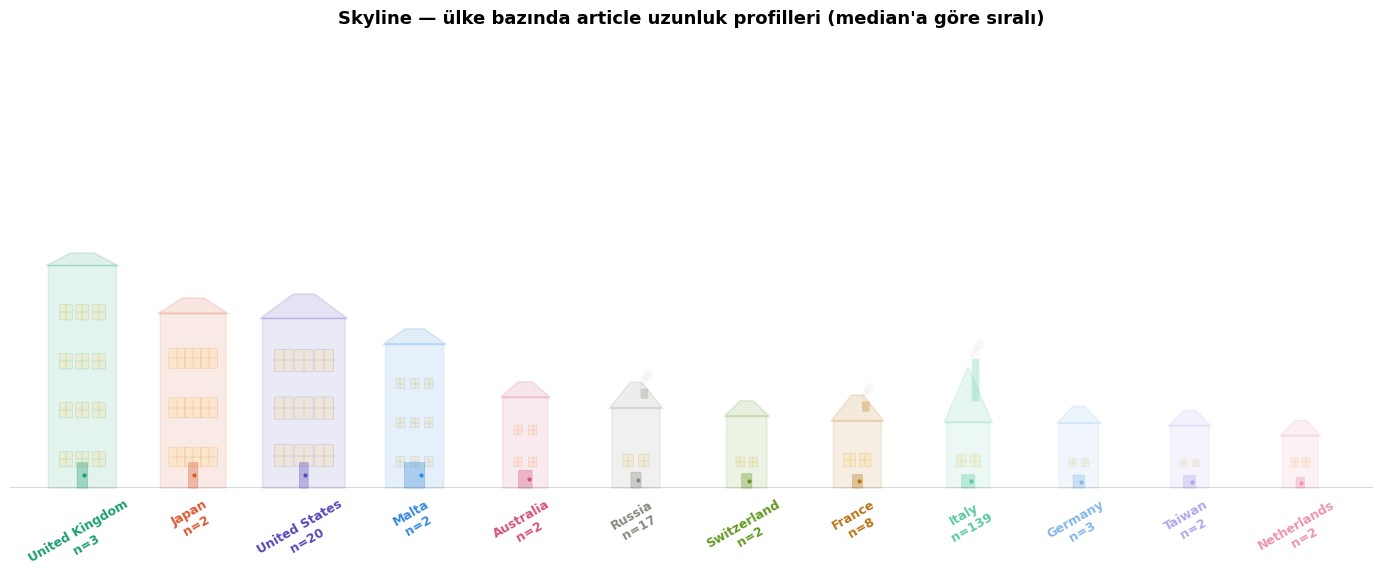

In [8]:
fig, ax = plt.subplots(figsize=(18, 6))

n_buildings = len(sorted_countries)
spacing = 1.3
ground_y = 0

for i, c in enumerate(sorted_countries):
    s = building_stats[c]
    color = colors_bldg[i % len(colors_bldg)]

    nMean = normalize_range(s['mean'], ranges['means'])
    nMed = normalize_range(s['median'], ranges['medians'])
    nStd = normalize_range(s['std'], ranges['stds'])
    nMode = normalize_range(s['mode'], ranges['modes'])
    nSkew = normalize_range(s['skew'], ranges['skews'])
    nKurt = normalize_range(s['kurt'], ranges['kurts'])

    cx = i * spacing + spacing / 2
    bW = 0.4 + nMean * 0.55
    bH = 0.6 + nMed * 2.0
    bx = cx - bW / 2
    by = ground_y

    # Çatı
    roof_h = 0.15 + nSkew * 0.5
    hip_inset = bW * 0.18 * (1 - nSkew)

    roof_verts = [
        (bx - 0.04, by + bH),
        (cx - hip_inset, by + bH + roof_h),
        (cx + hip_inset, by + bH + roof_h),
        (bx + bW + 0.04, by + bH),
        (bx - 0.04, by + bH),
    ]
    roof_path = Path(roof_verts, [Path.MOVETO]+[Path.LINETO]*3+[Path.CLOSEPOLY])
    ax.add_patch(patches.PathPatch(roof_path, fc=color, alpha=0.15, ec=color, lw=1.2))

    # Baca
    chimney_h = 0.08 + nKurt * 0.4
    chimney_w = 0.07
    chimney_x = cx + bW * 0.18
    chimney_base = by + bH + roof_h * 0.4

    if chimney_h > 0.1:
        ax.add_patch(patches.FancyBboxPatch(
            (chimney_x - chimney_w/2, chimney_base), chimney_w, chimney_h,
            boxstyle="round,pad=0.01", fc=color, alpha=0.3, ec='none'))
        for si in range(3):
            ax.add_patch(plt.Circle(
                (chimney_x + si*0.04 - 0.04, chimney_base + chimney_h + 0.05 + si*0.06),
                0.025 + si*0.015, fc='gray', alpha=0.06, ec='none'))

    # Duvar
    ax.add_patch(patches.FancyBboxPatch(
        (bx, by), bW, bH,
        boxstyle="round,pad=0.01", fc=color, alpha=0.12, ec=color, lw=1))

    # Pencereler
    win_size = 0.06 + nStd * 0.14
    n_floors = max(1, round(1 + nMed * 3))
    n_win = 3 if bW > 0.6 else 2

    for fl in range(n_floors):
        wy = by + 0.25 + fl * (bH - 0.3) / n_floors # Adjusted from 0.12 to 0.25
        for wi in range(n_win):
            wx = bx + (wi+1) * bW / (n_win+1) - win_size/2
            if wy + win_size * 1.2 < by + bH - 0.15:
                ax.add_patch(patches.FancyBboxPatch(
                    (wx, wy), win_size, win_size*1.2,
                    boxstyle="round,pad=0.01",
                    fc='#FFDC82', alpha=0.25, ec=color, lw=0.4))
                ax.plot([wx+win_size/2]*2, [wy, wy+win_size*1.2],
                        color=color, lw=0.3, alpha=0.4)
                ax.plot([wx, wx+win_size], [wy+win_size*0.6]*2,
                        color=color, lw=0.3, alpha=0.4)

    # Kapı
    door_w = 0.08 + nMode * 0.14
    door_h = min(bH * 0.18, 0.28)
    ax.add_patch(patches.FancyBboxPatch(
        (cx - door_w/2, by), door_w, door_h,
        boxstyle="round,pad=0.01", fc=color, alpha=0.35, ec=color, lw=0.5))
    ax.plot(cx + door_w/2 - 0.03, by + door_h/2, 'o', color=color, ms=2)

    # Label
    ax.text(cx, -0.12, c.title()+ f'\nn={s["n"]}', ha='center', va='top',
            fontsize=9, fontweight='bold', color=color, rotation=30)

# Zemin çizgisi
ax.axhline(y=ground_y, color='gray', lw=0.8, alpha=0.3)

ax.set_xlim(-0.2, n_buildings * spacing + 0.2)
ax.set_ylim(-0.5, 5.2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Skyline — ülke bazında article uzunluk profilleri (median\'a göre sıralı)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('skyline_chernoff.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Özet istatistik tablosu

In [9]:
# Tüm ülkelerin karşılaştırmalı istatistik tablosu
summary = []
for c in sorted_countries:
    data = df[df['country_normalized']==c]['text_length']
    summary.append({
        'Country': c.title(),
        'n': len(data),
        'Mean': round(data.mean()),
        'Median': round(data.median()),
        'Mode': round(data.mode().iloc[0]) if len(data.mode())>0 else None,
        'Std': round(data.std()) if len(data)>1 else None,
        'Skewness': round(skew(data), 2) if len(data)>=3 else None,
        'Kurtosis': round(kurtosis(data), 2) if len(data)>=3 else None,
        'Q1': round(data.quantile(0.25)),
        'Q3': round(data.quantile(0.75)),
        'IQR': round(data.quantile(0.75) - data.quantile(0.25)),
    })

summary_df = pd.DataFrame(summary).set_index('Country')
print(summary_df.to_string())


                  n   Mean  Median  Mode    Std  Skewness  Kurtosis    Q1     Q3    IQR
Country                                                                                
United Kingdom    3  11142   13938  1434   8655     -0.53     -1.50  7686  15996   8310
Japan             2  10432   10432   814  13603       NaN       NaN  5623  15242   9618
United States    20  15559   10070   590  16443      1.67      1.89  6035  16399  10364
Malta             2   8188    8188  6260   2726       NaN       NaN  7224   9151   1928
Australia         2   4304    4304  2926   1949       NaN       NaN  3615   4994   1378
Russia           17   5262    3516  1141   5279      1.93      2.38  2120   4917   2797
Switzerland       2   2924    2924  1311   2280       NaN       NaN  2117   3730   1612
France            8   5191    2572  1220   6474      1.95      2.28  1701   5263   3562
Italy           139   3694    2484  2769   5331      7.32     68.07  1438   4122   2683
Germany           3   2513    24

## 8. Sonuç

**Ana bulgu:** İtalyan mimarların yurtdışındaki eserleri, İtalya'dakilerden istatistiksel olarak anlamlı şekilde daha uzun Wikipedia article'larına sahiptir

Bu fark özellikle ABD'deki eserler için belirgindir: ABD'deki eserlerin median article uzunluğu İtalya'dakilerin yaklaşık 4 katıdır.

Bu bulgu, İngilizce Wikipedia'nın Amerikan merkezli editör bias'ını yansıtıyor olabilir.
